<a href="https://colab.research.google.com/github/StanleyArinze/st20338478_CMP7005-PRAC1/blob/main/CMP7005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP7005 Programming for Data Analysis

## Beijing Air Quality Prediction System

### Student Name: Stanley Arinze Ugwuoke

### Student ID: st20338478

### Module: CMP7005 Programming for Data Analysis

### Module Leader: Dr. Amrita Prasad

### Link to my Streamlit: https://cmp7005-air-quality-app.streamlit.app/

### Link for my Repo: https://github.com/StanleyArinze/st20338478_CMP7005-PRAC1

---

## Project Overview

This project focuses on analysing Beijing air quality data collected from selected monitoring stations. The study applies exploratory data analysis (EDA), machine learning techniques, and application development to predict PM2.5 concentration levels using pollutant and meteorological variables.

The project also includes the development of an interactive Streamlit web application for air quality prediction and AQI interpretation.


### Table of Contents

1. **Project Introduction**
   - Project aim and objectives
   - Dataset background
   - Importance of PM2.5 air quality prediction

2. **Importing Required Libraries**
   - Data handling libraries
   - Visualisation libraries
   - Machine learning libraries
   - Model saving and deployment libraries

3. **Creating Project Folder Structure**
   - Raw data folder
   - Processed data folder
   - Figures folder
   - Model folder

4. **Importing and Combining Datasets**
   - Loading selected Beijing air quality station datasets
   - Combining the datasets into one dataframe
   - Saving the combined dataset

5. **Exploratory Data Understanding**
   - Dataset shape
   - Column information
   - Data types
   - Missing value inspection
   - Summary statistics

6. **Data Preprocessing**
   - Handling missing values
   - Removing duplicate records
   - Cleaning categorical and numerical variables
   - Preparing the dataset for analysis and modelling

7. **Feature Engineering**
   - Datetime feature engineering
   - Seasonal feature engineering
   - Station type/category creation

8. **Statistical Analysis and Visualisation**
   - 8.1 PM2.5 distribution
   - 8.2 Correlation analysis
   - 8.3 Temperature distribution
   - 8.4 Pollution trend over time
   - 8.5 Seasonal pollution comparison
   - 8.6 Station-based pollution comparison

9. **Machine Learning Model Building**
   - Feature selection
   - Target variable selection
   - Train-test split
   - Feature scaling
   - Random Forest model training

10. **Model Evaluation**
    - Mean Squared Error
    - Root Mean Squared Error
    - R² Score
    - Actual vs Predicted PM2.5 graph
    - Feature importance analysis

11. **Saving the Machine Learning Model**
    - Saving the trained model
    - Saving the scaler
    - Preparing files for Streamlit deployment

12. **Streamlit Application Development**
    - Dataset overview page
    - Interactive visualisation page
    - Model output and PM2.5 prediction page
    - Air quality category interpretation

13. **Streamlit Cloud Deployment**
    - GitHub repository preparation
    - Requirements file
    - Streamlit Cloud deployment link

14. **Version Control**
    - GitHub repository structure
    - Commit history
    - Evidence of project development

15. **Conclusion**
    - Summary of findings
    - Model performance summary
    - Limitations and future improvements

# 1. Importing Required Libraries

This section imports all Python libraries required for:
- data handling,
- preprocessing,
- visualisation,
- machine learning,
- and model deployment.

The imported libraries support statistical analysis and predictive modelling throughout the project.

In [5]:

# IMPORT LIBRARIES


# Data handling libraries
import pandas as pd
import numpy as np
import glob
import os

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Save and load models
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Creating Project Folder Structure

To maintain proper project organisation, folders are created for:
- raw datasets,
- processed datasets,
- saved figures,
- machine learning models,
- and application files.

This improves project management and workflow structure.

In [6]:

# CREATE PROJECT FOLDERS


os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("app", exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


# 3. Importing and Combining Datasets

Four Beijing air quality datasets were selected from different monitoring stations:
- Guanyuan
- Dongsi
- Shunyi
- Huairou

The datasets were imported and merged into a single dataframe for analysis and modelling.

In [7]:

# IMPORT AND MERGE DATASETS


files = glob.glob("data/raw/*.csv")

dfs = []

for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

# Combine datasets
air_df = pd.concat(dfs, ignore_index=True)

print("Datasets merged successfully.")
print("Dataset Shape:", air_df.shape)

Datasets merged successfully.
Dataset Shape: (140256, 18)


# 4. Exploratory Data Understanding

This section investigates:
- dataset dimensions,
- data types,
- missing values,
- and dataset structure.

Understanding the dataset is important before preprocessing and model development.

In [8]:

# VIEW DATASET


air_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


### Interpretation

The dataset contains both numerical and categorical variables. Some pollutant variables contain missing values which require preprocessing before modelling.

In [9]:

# CHECK MISSING VALUES


air_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,3232
PM10,2307
SO2,3413
NO2,5264
CO,8550


### Interpretation

Missing values were identified mainly within pollutant-related variables such as PM2.5 and CO. These missing values must be handled to improve model performance and data quality.

# 5. Data Preprocessing

This section prepares the dataset for machine learning by:
- handling missing values,
- creating datetime features,
- engineering new features,
- and improving dataset quality.

In [10]:

# HANDLE MISSING VALUES


# Fill numerical missing values using median
numeric_cols = air_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    air_df[col] = air_df[col].fillna(air_df[col].median())

# Fill categorical missing values using mode
categorical_cols = air_df.select_dtypes(include="object").columns

for col in categorical_cols:
    air_df[col] = air_df[col].fillna(air_df[col].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [11]:

# VERIFY MISSING VALUES


air_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


### Interpretation

All missing values were successfully handled using median imputation for numerical variables and mode imputation for categorical variables.

# 6. Datetime Feature Engineering

Datetime features were created by combining:
- year,
- month,
- day,
- and hour columns.

This enables time-series analysis and seasonal exploration.

In [12]:

# CREATE DATETIME COLUMN


air_df["datetime"] = pd.to_datetime(
    air_df[["year", "month", "day", "hour"]]
)

air_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.0,40.0,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou,2013-03-01 01:00:00
2,3,2013,3,1,2,4.0,4.0,7.0,40.0,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,900.0,45.0,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.0,40.0,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou,2013-03-01 04:00:00


# 7. Seasonal Feature Engineering

A seasonal classification feature was created to analyse how PM2.5 concentration changes across different seasons.

In [14]:

# CREATE SEASON COLUMN


def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"

air_df["season"] = air_df["month"].apply(get_season)

air_df[["month", "season"]].head()

,month,season
0,3,Spring
1,3,Spring
2,3,Spring
3,3,Spring
4,3,Spring


# 8. Statistical Analysis and Visualisation

This section explores:
- pollutant distributions,
- correlations,
- temporal patterns,
- and relationships between variables using graphical visualisations.

## 8.1 PM2.5 Distribution

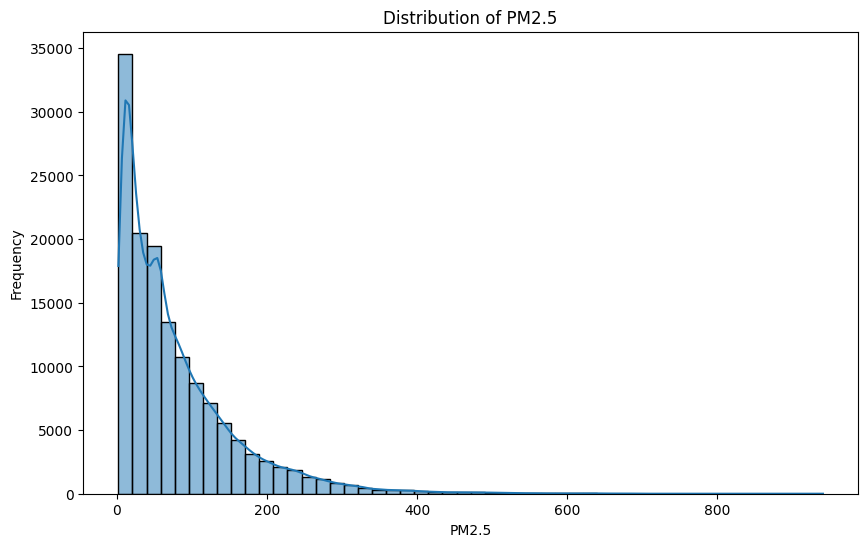

In [15]:

# PM2.5 DISTRIBUTION


plt.figure(figsize=(10,6))

sns.histplot(air_df["PM2.5"], bins=50, kde=True)

plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

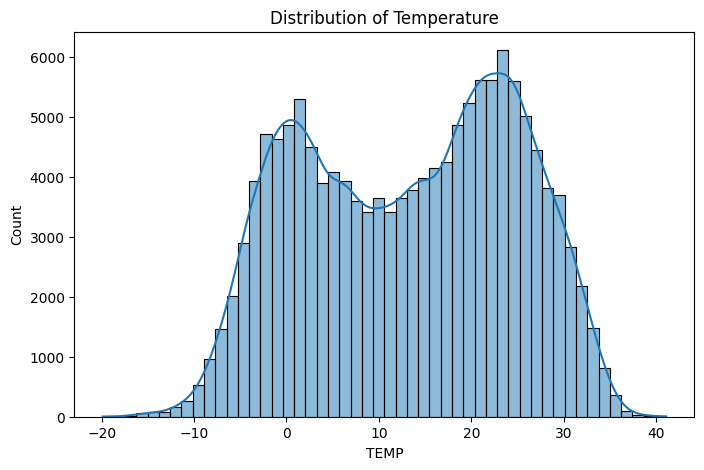

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(air_df["TEMP"], bins=50, kde=True)
plt.title("Distribution of Temperature")
plt.show()

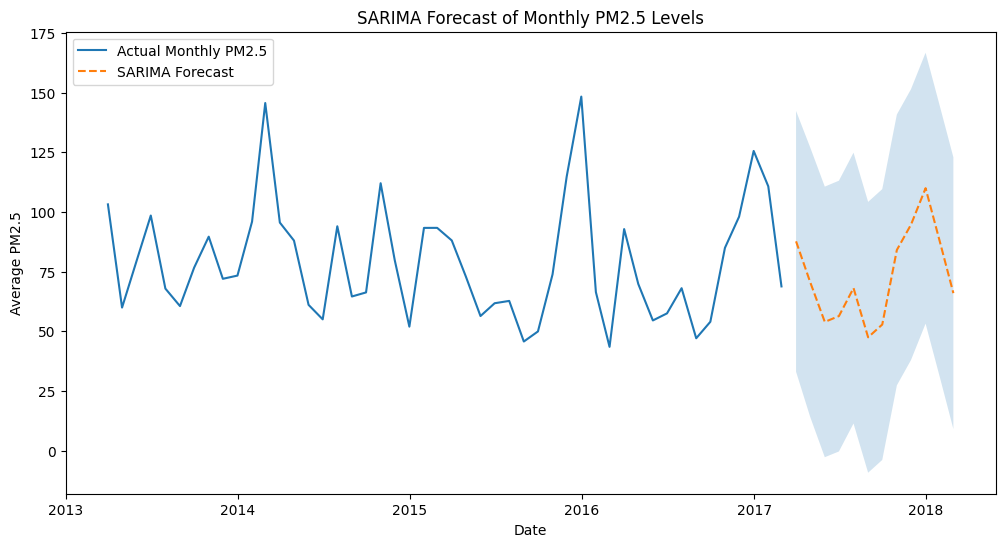

In [17]:
# ==========================================
# SARIMA TIME SERIES FORECASTING
# ==========================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Ensure datetime is in correct format
air_df["datetime"] = pd.to_datetime(air_df["datetime"])

# Create monthly average PM2.5 time series
monthly_pm25 = air_df.set_index("datetime")["PM2.5"].resample("M").mean()

# Fit SARIMA model
sarima_model = SARIMAX(
    monthly_pm25,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

# Forecast next 12 months
forecast = sarima_result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot actual and forecast values
plt.figure(figsize=(12,6))

plt.plot(monthly_pm25, label="Actual Monthly PM2.5")
plt.plot(forecast_mean, label="SARIMA Forecast", linestyle="--")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2
)

plt.title("SARIMA Forecast of Monthly PM2.5 Levels")
plt.xlabel("Date")
plt.ylabel("Average PM2.5")
plt.legend()
plt.show()

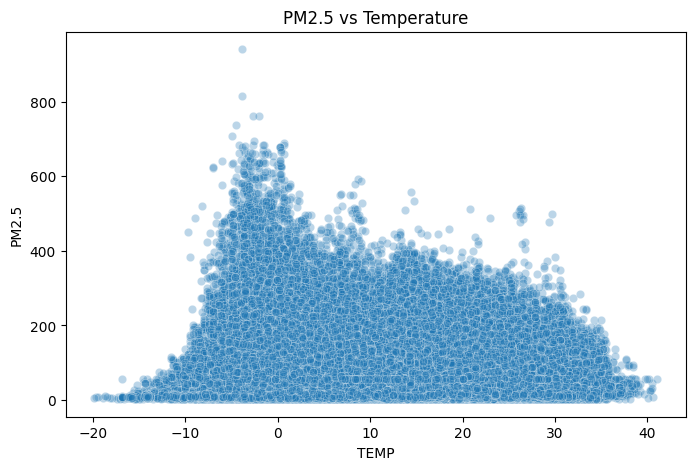

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="TEMP", y="PM2.5", data=air_df, alpha=0.3)
plt.title("PM2.5 vs Temperature")
plt.show()

In [19]:
air_df.columns


# CREATE STATION TYPE COLUMN


urban_stations = ["Dongsi", "Guanyuan"]

air_df["station_type"] = air_df["station"].apply(
    lambda x: "Urban" if x in urban_stations else "Suburban"
)

print("station_type column created successfully.")

station_type column created successfully.


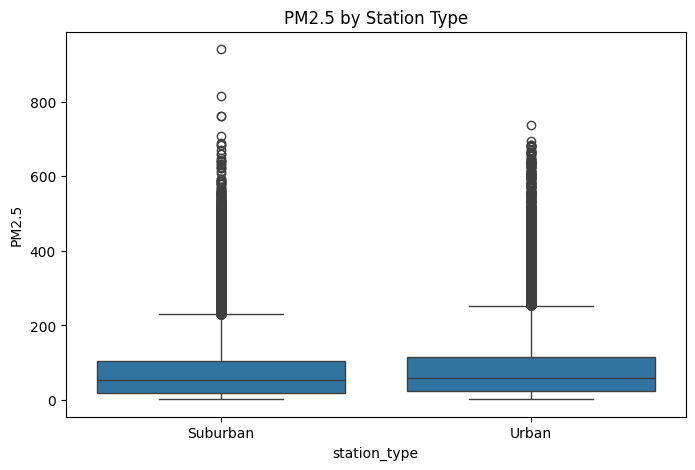

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="station_type",
    y="PM2.5",
    data=air_df
)

plt.title("PM2.5 by Station Type")

plt.show()

## 8.2 Correlation Analysis

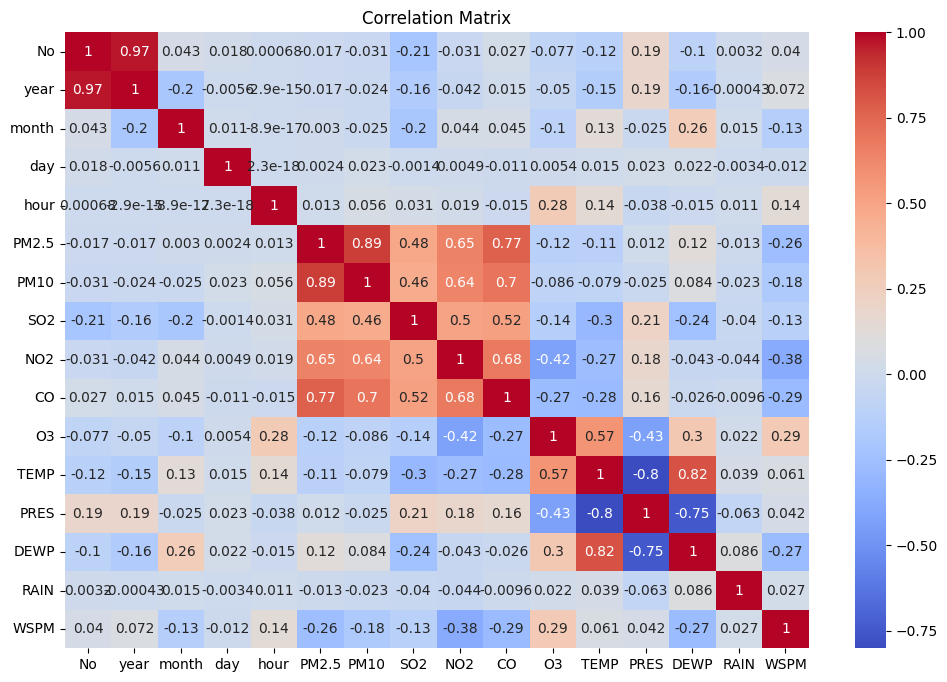

In [21]:

# CORRELATION HEATMAP


numeric_df = air_df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Interpretation
PM2.5 shows strong positive correlations with PM10, CO, and NO2, indicating that these pollutants significantly influence air quality levels.

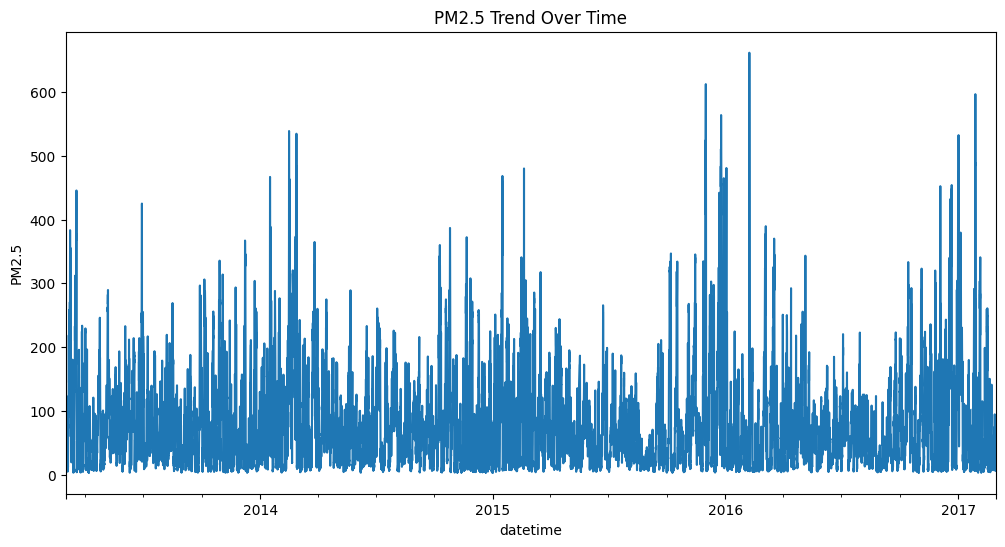

In [22]:
plt.figure(figsize=(12,6))
air_df.groupby("datetime")["PM2.5"].mean().plot()
plt.title("PM2.5 Trend Over Time")
plt.ylabel("PM2.5")
plt.show()

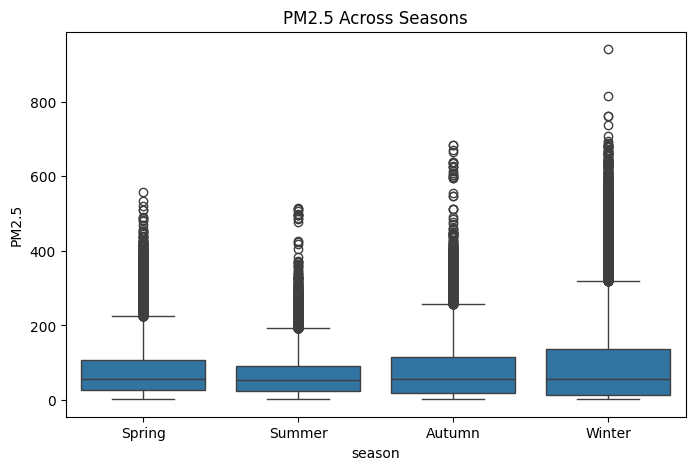

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="season", y="PM2.5", data=air_df)
plt.title("PM2.5 Across Seasons")
plt.show()

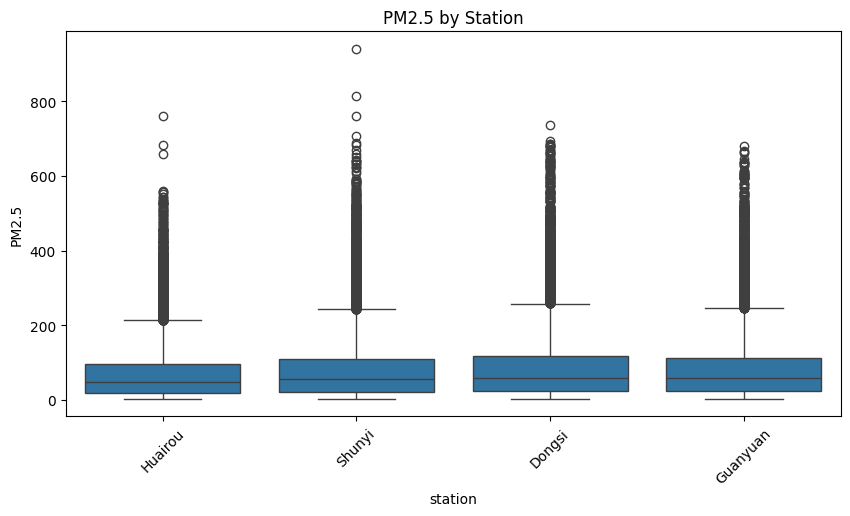

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x="station", y="PM2.5", data=air_df)
plt.title("PM2.5 by Station")
plt.xticks(rotation=45)
plt.show()

# 9. Machine Learning Model Development

A Random Forest Regressor model was developed to predict PM2.5 concentration using pollutant and meteorological variables.

In [26]:

# FEATURE SELECTION


features = ["PM10", "SO2", "NO2", "CO", "O3",
            "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

X = air_df[features]

y = air_df["PM2.5"]

In [27]:

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training and testing sets created.")

Training and testing sets created.


In [28]:

# FEATURE SCALING


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [29]:

# MODEL TRAINING


model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


# 10. Model Evaluation

The Random Forest model was evaluated using:
- Mean Squared Error (MSE),
- Root Mean Squared Error (RMSE),
- and R² Score.

These metrics help measure prediction accuracy and model performance.

In [30]:

# MODEL EVALUATION


# Generate predictions
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 430.41041707779993
RMSE: 20.746335027609092
R² Score: 0.9300449626228748


### Interpretation

The Random Forest model achieved strong predictive performance with a high R² score and relatively low RMSE value. This indicates that the model successfully learned relationships between pollutant and meteorological variables.

# 11. Actual vs Predicted PM2.5 Values

The following visualisation compares actual PM2.5 observations with model predictions.

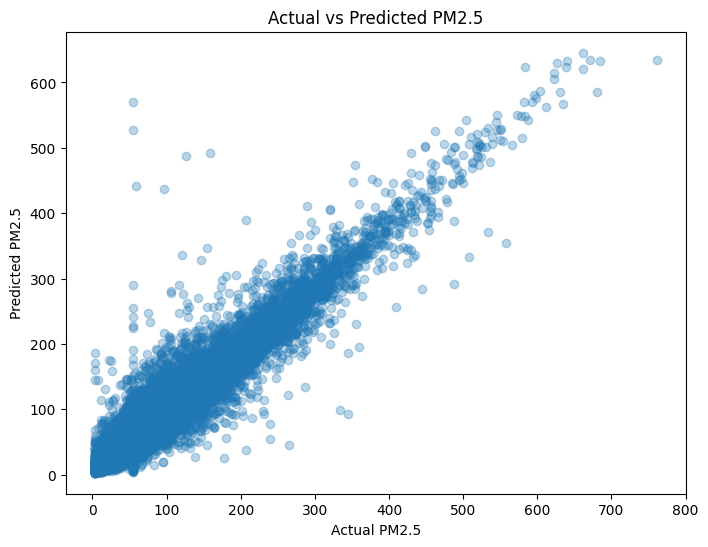

In [31]:

# ACTUAL VS PREDICTED GRAPH


plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual PM2.5")

plt.ylabel("Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5")

plt.show()

### Interpretation

Most prediction points align closely with actual PM2.5 values, demonstrating good model accuracy. Minor deviations occur mainly at extremely high pollution levels.

# 12. Feature Importance Analysis

Feature importance analysis helps identify which variables contribute most to PM2.5 prediction.

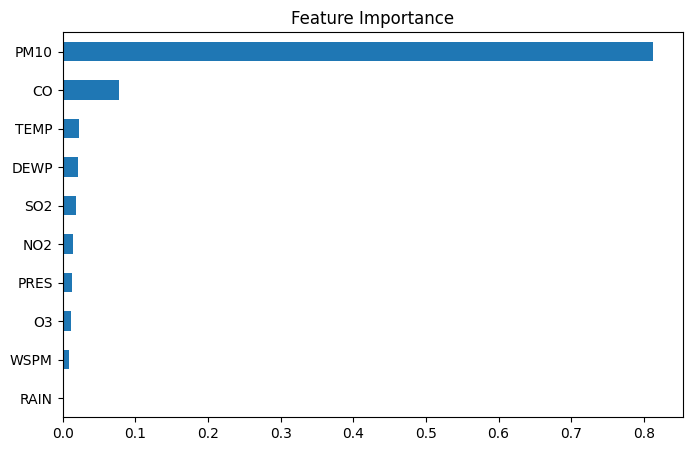

In [32]:

# FEATURE IMPORTANCE


importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

### Interpretation

PM10, CO, and NO2 were among the most influential variables for predicting PM2.5 concentration, indicating strong relationships between particulate and gaseous pollutants.

# 13. Saving the Machine Learning Model

The trained model and scaler were exported using Joblib to support deployment within the Streamlit application.

In [39]:
import joblib
import os

# Save model and scaler in the current Colab folder
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files saved successfully!")
print(os.listdir())

Files saved successfully!
['.config', 'figures', 'app', 'model.pkl', 'models', 'scaler.pkl', 'data', 'sample_data']


In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

# Smaller Random Forest model for Streamlit Cloud deployment
small_model = RandomForestRegressor(
    n_estimators=15,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# Train the smaller model
small_model.fit(X_train_scaled, y_train)

# Test the model
y_pred_small = small_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_small)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_small)

print("Small Model RMSE:", rmse)
print("Small Model R2 Score:", r2)

# Save compressed model and scaler
joblib.dump(small_model, "model.pkl", compress=9)
joblib.dump(scaler, "scaler.pkl", compress=9)

# Check file sizes
model_size = os.path.getsize("model.pkl") / (1024 * 1024)
scaler_size = os.path.getsize("scaler.pkl") / (1024 * 1024)

print(f"model.pkl size: {model_size:.2f} MB")
print(f"scaler.pkl size: {scaler_size:.2f} MB")

Small Model RMSE: 23.11917157456525
Small Model R2 Score: 0.913127812964809
model.pkl size: 0.53 MB
scaler.pkl size: 0.00 MB


In [41]:
import pandas as pd
import glob
import os

# Load the 4 raw CSV files
files = glob.glob("data/raw/*.csv")

dfs = []

for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

air_df = pd.concat(dfs, ignore_index=True)

# Create datetime
air_df["datetime"] = pd.to_datetime(
    air_df[["year", "month", "day", "hour"]]
)

# Add station type
urban_stations = ["Dongsi", "Guanyuan"]

air_df["station_type"] = air_df["station"].apply(
    lambda x: "Inner (Urban)" if x in urban_stations else "Outer (Suburban)"
)

# Handle missing values
num_cols = air_df.select_dtypes(include=["float64", "int64"]).columns

for col in num_cols:
    air_df[col] = air_df[col].fillna(air_df[col].median())

if "wd" in air_df.columns:
    air_df["wd"] = air_df["wd"].fillna(air_df["wd"].mode()[0])

# Remove duplicates
air_df = air_df.drop_duplicates()

# Add season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

air_df["season"] = air_df["month"].apply(get_season)

# Save final cleaned CSV
air_df.to_csv("beijing_air_quality_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print(air_df.shape)

Cleaned dataset saved successfully.
(140256, 21)


In [42]:
from google.colab import files
files.download("beijing_air_quality_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## References

1. W3schools.com. (2016). W3Schools.com. [online] Available at: https://www.w3schools.com/python/python_dictionaries.asp [Accessed 5 May 2026].
‌

2. Google for Developers. (2024). Python Dict and File. [online] Available at: https://developers.google.com/edu/python/dict-files [Accessed 6 May 2026].

3. Ibm.com. (2025). IBM SPSS Software. [online] Available at: https://www.ibm.com/products/spss?utm_content=SRCWW&p1=Search&p4=103144555&p5=b&p9=171769525826&gclsrc=aw.ds&gad_source=1&gad_campaignid=22033591589&gbraid=0AAAAA-h2TOE5iybm4bSkyMB053FZRSyfP&gclid=CjwKCAjwq6DQBhBVEiwA4ZD5XMl8wIvMyHxbDKdCVbkPl83y8k36llK_zi8eyLUypNlNMkoDiByWtRoCyFMQAvD_BwE [Accessed 10 May 2026].
‌
4. Youtube.com. (2026). [online] Available at: https://www.youtube.com/watch?v=ZZ4B0QUHuNc&list=PLtqF5YXg7GLmCvTswG32NqQypOuYkPRUE [Accessed 9 May 2026].
‌